# Imports

In [1]:
# JAX setup
import jax

# Enable 64-bit precision in JAX
jax.config.update("jax_enable_x64", True)

# Which accelerator to use
# jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_platforms", "cuda,cpu")


In [2]:
import itertools

import cmcrameri.cm as cmc
import equinox as eqx
import gstools as gs
import jax.numpy as jnp
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.axes_grid1 import ImageGrid
from nanopinv._typing import Array, Float
from nanopinv.distribution import MultivariateNormalCholesky
from nanopinv.physics.eikonal import build_travel_time_points
from nanopinv.sampler import (
    ExtendedMetropolisChain,
    ParallelTemperingSampler,
    ProposalDistribution,
    initialize_betas,
)
from nanopinv.types import ObservationsUnivariate
from nanopinv.utils import StatefulRNGKey, make_pytree_spec
from nanopinv.variance import get_distance_matrix
from scipy.io import loadmat

# for reloading submodules without restarting kernel
%load_ext autoreload
%autoreload 2

E0425 11:40:13.094866 3009059 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 17.64GiB (18937970688 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0425 11:40:13.094985 3009059 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 15.87GiB (17044172800 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0425 11:40:13.095102 3009059 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 14.29GiB (15339755520 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0425 11:40:13.095202 3009059 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 12.86GiB (13805779968 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0425 11:40:13.095300 3009059 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 11.57GiB (12425201664 by

In [3]:
sns.set_theme(context="paper", style="whitegrid")
skey = StatefulRNGKey(0)
mem = joblib.Memory(".joblib_cache", verbose=0)

A4_WIDTH_IN = 210 / 25.4
EXPORT_KWARGS = {
    "bbox_inches": "tight",
    "dpi": 600,
}

# Introduction

This notebook gives some hints in terms of how to approach the assignement and get to grips with the PINV package. 

Please note the PINV package is a not a finished package, it is still under development by T. Meier-Hansen so some variables and functions in the package are not finished or some parts are hard-coded in the source code. However, the package contains all the functions and variable settings needed to solve the assignment. It is highly recommended that you walk though the tutorial notebooks first, they are very much relevant, and you may well get stuck if you do not look at these first.

Additionally, it can be a good idea to look in the "sippi.pdf" file in literature folder, as it provides explanations of similar variables in the MATLAB version of the package and the naming convention has been kept the same. So a strategy for understanding a function or variable below could be (in prioritized order):
- Search for the function/variable name or slight variations in "sippi.pdf", "Hansen_etal_2013_SIPPI1.pdf" and "Hansen_etal_2013_SIPPI2.pdf". Read! 
- Experiment with a small number of iterations and see which effect different variables have
- Look into source code (search function in VScode is very helpful here), but keep in mind that this requires reading the code - it does not have a lot of comments. Specifically line 107-132 in ```extended_metropolis.py``` provides a bit of insight into what order things are called in.

Make sure you can run everything below and make some test diagnostic plots before you start to run a large number of iterations (this can take a long time!). Note that you can load the hdf5 files after the run has completed, so if you run the model and later want to look at results you can load them from the hdf5, instead of running everything again. 

# Load data

In [4]:
# Given by assignment
data_raw = loadmat("data/BHRS_2D.mat")
data_obs = data_raw["traveltimes"].squeeze()
data_std = data_raw["traveltimes_std"].squeeze()
ndata, ndim = data_raw["sources"].shape
sources_raw = data_raw["sources"].squeeze()
receivers_raw = data_raw["receivers"].squeeze()

In [5]:
# sources and receivers are 3D, but third dimension is all zeros
assert np.allclose(sources_raw[:, 2], 0.0)
assert np.allclose(receivers_raw[:, 2], 0.0)

# Remove third dimension to make it 2D problem, I guess this should have been done in the starting notebook...?
ndim = 2
sources = sources_raw[:, :2]
receivers = receivers_raw[:, :2]
ndata = sources.shape[0]
assert receivers.shape[0] == ndata

In [6]:
# Observations
data_obs = data_raw["traveltimes"].squeeze()
data_std = data_raw["traveltimes_std"].squeeze().astype(np.float64)

# We have univariate observations (according to the assumptions of our a priori model),
# so we can use optimized Observations class here
assert (data_std == 2.0).all()
obs = ObservationsUnivariate(data_obs=data_obs, data_std=2.0)
# TODO: Maybe convert to single precision?

In [7]:
_data_grid_all_x = np.hstack((sources[:, 0], receivers[:, 0]))
_data_grid_all_y = np.hstack((sources[:, 1], receivers[:, 1]))

data_grid_min_x = np.min(_data_grid_all_x)
data_grid_max_x = np.max(_data_grid_all_x)
data_grid_min_y = np.min(_data_grid_all_y)
data_grid_max_y = np.max(_data_grid_all_y)

In [8]:
model_grid_dx = 0.25
model_grid_dy = model_grid_dx

model_grid_x = np.arange(
    data_grid_min_x, data_grid_max_x + model_grid_dx, model_grid_dx
)
model_grid_y = np.arange(
    data_grid_min_y, data_grid_max_y + model_grid_dy, model_grid_dy
)
model_grid_X, model_grid_Y = np.meshgrid(model_grid_x, model_grid_y, indexing="ij")
model_grid_shape = model_grid_X.shape  # (Nx, Ny)
model_grid_extent = [
    np.min(model_grid_x),
    np.max(model_grid_x),
    np.min(model_grid_y),
    np.max(model_grid_y),
]

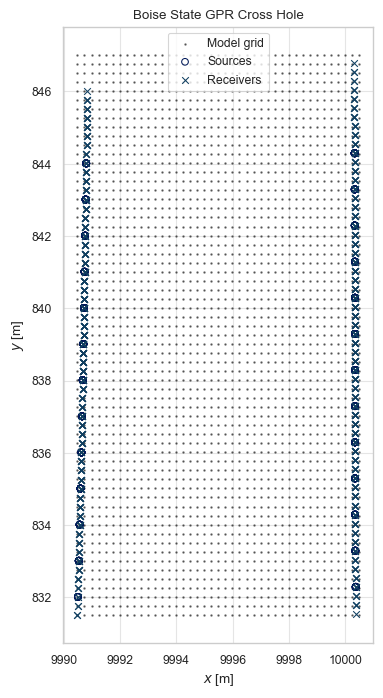

In [9]:
plt.figure(figsize=(4, 8))
colors = cmc.batlow.resampled(10)
plt.scatter(model_grid_X, model_grid_Y, color="k", s=1, label="Model grid", alpha=0.5)

plt.scatter(
    sources[:, 0],
    sources[:, 1],
    color=colors(0),
    label="Sources",
    marker="o",
    facecolors="none",
    lw=0.75,
)
plt.scatter(
    receivers[:, 0],
    receivers[:, 1],
    color=colors(1),
    label="Receivers",
    marker="x",
    lw=0.75,
)
plt.legend(loc="upper center")
plt.xlabel("$x$ [m]")
plt.ylabel("$y$ [m]")
plt.gca().get_xaxis().get_major_formatter().set_useOffset(False)
plt.title("Boise State GPR Cross Hole")
plt.grid(True, alpha=0.5)
# c_sources(0)


In [10]:
def plot_field(
    field,
    ax=None,
    title: str | None = None,
    extent=model_grid_extent,
    plot_grid_points: bool = True,
    plot_sources_receivers: bool = True,
    plot_cbar: bool = True,
    plot_water_table: bool = True,
    water_table_elevation: float = 844.0,
    auto_truncate: bool = True,
    cbar_label: str = "Value",
    grid_points=(model_grid_X, model_grid_Y),
    sources=sources,
    receivers=receivers,
    **kwargs,
):
    if ax is None:
        _, ax = plt.subplots(figsize=kwargs.get("figsize", (4, 8)))

    if auto_truncate:
        trunc_y = extent[3]
        truncate_mask = grid_points[1] < trunc_y
        grid_points = (grid_points[0][truncate_mask], grid_points[1][truncate_mask])
        sources = sources[sources[:, 1] < trunc_y]
        receivers = receivers[receivers[:, 1] < trunc_y]

    im = ax.imshow(
        field.T,
        origin="lower",
        extent=extent,
        cmap=kwargs.get("cmap", cmc.batlow),
    )

    if plot_cbar:
        cbar = plt.colorbar(im, ax=ax, location="top", pad=0.01, label=cbar_label)

    if plot_grid_points:
        ax.scatter(
            grid_points[0],
            grid_points[1],
            color="k",
            s=1,
            label="Model grid",
            alpha=0.5,
        )

    if plot_sources_receivers:
        ax.scatter(
            receivers[:, 0],
            receivers[:, 1],
            color=cmc.buda(0.999),
            label="Receivers",
            marker="x",
            lw=0.75,
        )
        ax.scatter(
            sources[:, 0],
            sources[:, 1],
            color=cmc.buda(0),
            label="Sources",
            marker="o",
            facecolors="none",
            lw=0.75,
        )

    if plot_water_table:
        ax.axhline(
            water_table_elevation,
            color="k",
            ls="--",
            label="Water Table",
        )

    ax.legend(
        loc="lower right",
        bbox_to_anchor=(1.0, 1.13),
        frameon=True,
        facecolor=plt.cm.binary(0.3),
    )
    ax.set_xlabel("$x$ [m]")
    ax.set_ylabel("$y$ [m]")
    ax.get_xaxis().get_major_formatter().set_useOffset(False)

    if title is not None:
        plt.title(title, x=0.0, y=1.13, size=12, horizontalalignment="left")
    ax.grid(True, alpha=0.5)

    return ax

# Prior

In [11]:
# Load and preprocess prior data
data_empirical_prior_raw = loadmat("data/BHRS_prior.mat")

empirical_prior_model_grid_x = data_empirical_prior_raw["x"].squeeze()
empirical_prior_model_grid_y = data_empirical_prior_raw["y"].squeeze()
empirical_prior_model_grid_shape = (
    empirical_prior_model_grid_x.size,
    empirical_prior_model_grid_y.size,
)

empirical_prior_samples = [
    data_empirical_prior_raw["prior_0"],
    data_empirical_prior_raw["prior_1"],
    data_empirical_prior_raw["prior_2"],
]
empirical_prior_samples_arr = np.asarray(empirical_prior_samples)

empirical_prior_mean = np.mean(empirical_prior_samples)

## Variogram and Covariance Model

In [12]:
# Estimate variogram - Cache to disk since it takes a few minutes to run
bin_centers_est, gamma_est = mem.cache(gs.vario_estimate)(
    (empirical_prior_model_grid_x, empirical_prior_model_grid_y),
    empirical_prior_samples,
    mesh_type="structured",
)

Text(0.5, 1.0, 'Empirical variogram of prior samples')

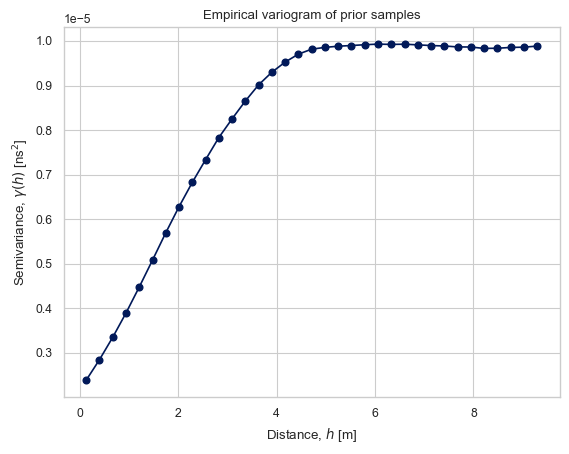

In [13]:
plt.plot(bin_centers_est, gamma_est, "o-", color=colors(0))
plt.xlabel("Distance, $h$ [m]")
plt.ylabel("Semivariance, $γ(h)$ [ns$^2$]")
plt.title("Empirical variogram of prior samples")

/home/jkl/Code/DTU-30760-Inverse-Problems-and-Machine-Learning-in-Earth-and-Space-Physics/.pixi/envs/cuda/lib/python3.14/site-packages/gstools/covmodel/tools.py:552: AttributeWarning: Dimension 2 is not appropriate for this model.
  warnings.warn(


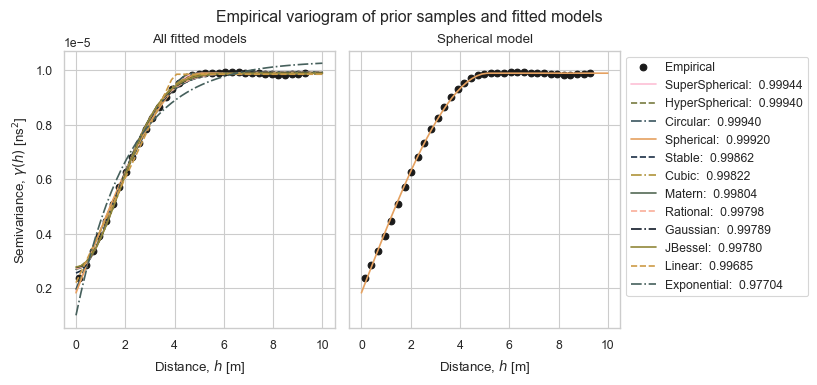

In [14]:
# Inspired by: https://geostat-framework.readthedocs.io/projects/gstools/en/v1.3.0/examples/03_variogram/01_find_best_model.html?highlight=variogram
models = {
    "Gaussian": gs.Gaussian,
    "Exponential": gs.Exponential,
    "Matern": gs.Matern,
    "Stable": gs.Stable,
    "Rational": gs.Rational,
    "Cubic": gs.Cubic,
    "Linear": gs.Linear,
    "Circular": gs.Circular,
    "Spherical": gs.Spherical,
    "HyperSpherical": gs.HyperSpherical,
    "SuperSpherical": gs.SuperSpherical,
    "JBessel": gs.JBessel,
}

fits = []
for model_name, model in models.items():
    fit_model = model(dim=2)
    # Note: gtol _very_ important as otherwise it does not go to convergence since residuals are just natively very small here
    para, pcov, r2 = fit_model.fit_variogram(
        bin_centers_est, gamma_est, return_r2=True, curve_fit_kwargs={"gtol": 1e-14}
    )
    fits.append(
        {
            "model_name": model_name,
            "model_class": model,
            "fit_model": fit_model,
            "para": para,
            "r2": r2,
        }
    )

fits = sorted(fits, key=lambda x: x["r2"], reverse=True)

# Plot estimated variogram and covariance model fits
fig, (ax_all, ax_select) = plt.subplots(
    1, 2, figsize=(A4_WIDTH_IN, 4), sharey=True, sharex=True
)
fig.subplots_adjust(wspace=0.05)

ax_all.scatter(bin_centers_est, gamma_est, color="k", label="Empirical")

# x_max = np.max(bin_centers_est)
x_max = 10.0
colors = cmc.batlowKS
styles = itertools.cycle(["-", "--", "-."])
for i, fit in enumerate(fits):
    style = next(styles)
    fit["i"] = i
    fit["style"] = style
    fit["color"] = colors(i + 1)
    fit["fit_model"].plot(
        x_max=x_max,
        ax=ax_all,
        label=f"{fit['model_name']}:  {fit['r2']:.5f}",
        color=fit["color"],
        linestyle=style,
    )


# Select model plot
select_fit = next(fit for fit in fits if fit["model_name"] == "Spherical")
select_fit["fit_model"].plot(
    x_max=x_max,
    ax=ax_select,
    label=f"{select_fit['model_name']}:  {select_fit['r2']:.5f}",
    color=select_fit["color"],
)
ax_select.scatter(bin_centers_est, gamma_est, color="k")


handles, labels = ax_all.get_legend_handles_labels()
ax_select.legend(handles, labels, loc="upper left", bbox_to_anchor=(1, 1))
ax_all.legend().remove()

ax_all.set_xlabel("Distance, $h$ [m]")
ax_select.set_xlabel("Distance, $h$ [m]")
ax_all.set_ylabel("Semivariance, $γ(h)$ [ns$^2$]")

fig.suptitle("Empirical variogram of prior samples and fitted models", y=0.95)
ax_all.set_title("All fitted models")
ax_select.set_title(f"{select_fit['model_name']} model")

fig.tight_layout()


In [15]:
covariance_model = select_fit["fit_model"]
covariance_model

Spherical(dim=2, var=8.06e-06, len_scale=5.16, nugget=1.83e-06)

## Covariance Matrix

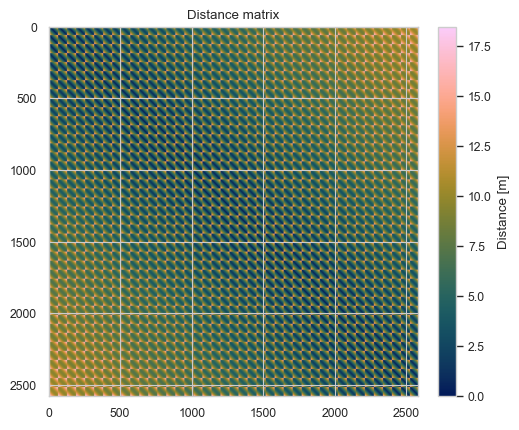

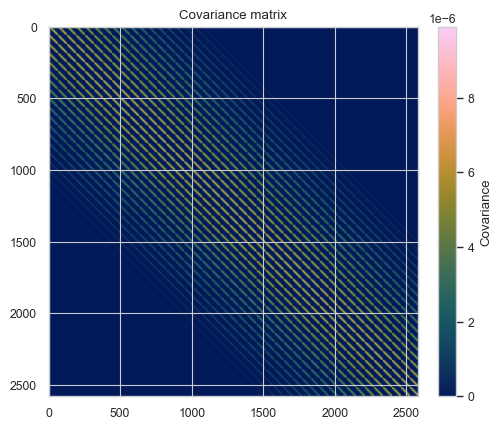

In [16]:
distance_matrix = get_distance_matrix(model_grid_x, model_grid_y)
cov_matrix = covariance_model.covariance(distance_matrix)

# Crucial: Add nugget to covariance matrix diagonal!
cov_matrix += np.identity(cov_matrix.shape[0]) * covariance_model.nugget

# plt.figure()
# plt.pcolormesh(model_grid_X, model_grid_Y, cov_matrix)
# # plt.imshow(cov_matrix.T, origin="lower")
# # plt.matshow(distance_matrix)
# plt.colorbar(label="Distance [m]")

plt.figure()
plt.title("Distance matrix")
plt.imshow(distance_matrix, cmap=cmc.batlow)
plt.colorbar(label="Distance [m]", fraction=0.046, pad=0.04)

plt.figure()
plt.title("Covariance matrix")
plt.imshow(cov_matrix, cmap=cmc.batlow)
plt.colorbar(label="Covariance", fraction=0.046, pad=0.04)

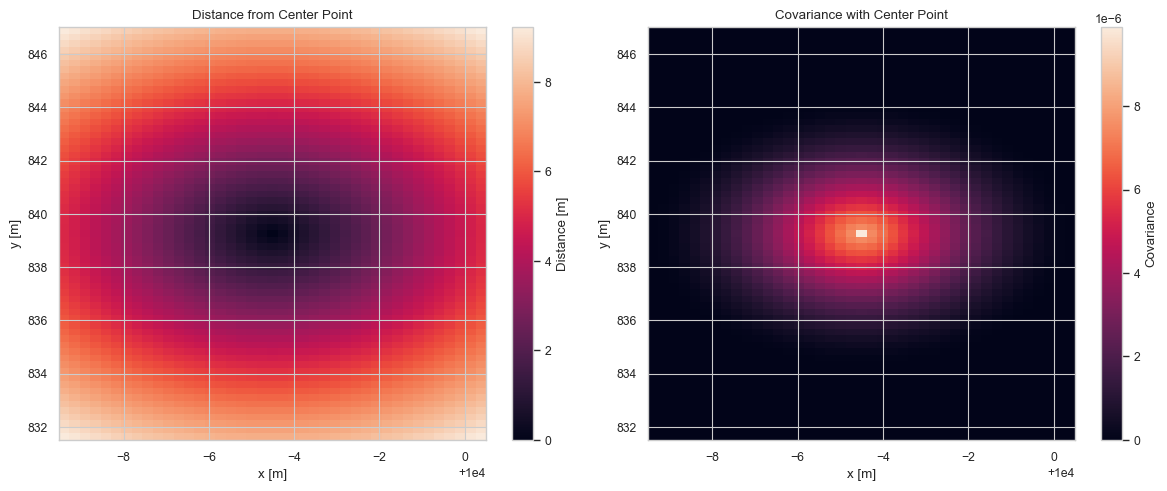

In [17]:
# Note: LLM
Nx = len(model_grid_x)
Ny = len(model_grid_y)

# 1. Find the flattened index of the center point
# Under "ij" indexing, y varies fastest, so index = i * Ny + j
center_i = Nx // 2
center_j = Ny // 2
center_idx = center_i * Ny + center_j

# 2. Extract the row and reshape back to (Nx, Ny)
dist_field = distance_matrix[center_idx, :].reshape(Nx, Ny)
cov_field = cov_matrix[center_idx, :].reshape(Nx, Ny)

# Physical extent for the plot axes
extent = [model_grid_x[0], model_grid_x[-1], model_grid_y[0], model_grid_y[-1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 3. Transpose (.T) and set origin='lower' to match Cartesian x-y plotting
im0 = axes[0].imshow(dist_field.T, origin="lower", extent=extent, aspect="auto")
axes[0].set_title("Distance from Center Point")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
fig.colorbar(im0, ax=axes[0], label="Distance [m]")

im1 = axes[1].imshow(cov_field.T, origin="lower", extent=extent, aspect="auto")
axes[1].set_title("Covariance with Center Point")
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("y [m]")
fig.colorbar(im1, ax=axes[1], label="Covariance")

plt.tight_layout()
plt.show()


## Prior Distribution

In [18]:
prior_dist = MultivariateNormalCholesky.from_covariance(
    cov=cov_matrix, mean=empirical_prior_mean, shape=model_grid_shape
)


In [19]:
# Note: No need to keep big arrays on GPU around, clean up
del distance_matrix
del cov_matrix

## Plot Prior Samples

In [20]:
# We want to make a separate distribution that generates square fields such that they
# match the empirical prior
model_grid_x_plot = np.linspace(0.0, 20.0, 100)
model_grid_y_plot = np.linspace(0.0, 20.0, 100)
multi_grid_shape_plot = (len(model_grid_x_plot), len(model_grid_y_plot))

distance_matrix_plot = get_distance_matrix(model_grid_x_plot, model_grid_y_plot)
cov_matrix_plot = covariance_model.covariance(distance_matrix_plot)

prior_dist_plot = MultivariateNormalCholesky.from_covariance(
    cov=cov_matrix_plot, mean=empirical_prior_mean, shape=multi_grid_shape_plot
)

Text(0.5, 0.98, 'Samples from empirical prior and estimated distribution')

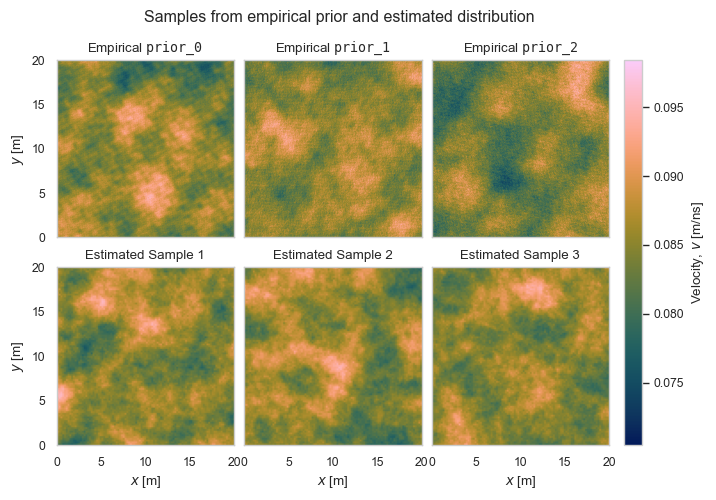

In [21]:
new_prior_samples = [
    prior_dist_plot(skey()),
    prior_dist_plot(skey()),
    prior_dist_plot(skey()),
]

samples_to_plot = empirical_prior_samples + new_prior_samples
names = [
    "Empirical $\\mathtt{prior\\_0}$",
    "Empirical $\\mathtt{prior\\_1}$",
    "Empirical $\\mathtt{prior\\_2}$",
    "Estimated Sample 1",
    "Estimated Sample 2",
    "Estimated Sample 3",
]

vmax = max(
    np.asarray(empirical_prior_samples).max(), np.asarray(new_prior_samples).max()
)
vmin = min(
    np.asarray(empirical_prior_samples).min(), np.asarray(new_prior_samples).min()
)
extent_empirical_prior_plot = [
    model_grid_x_plot[0],
    model_grid_x_plot[-1],
    model_grid_y_plot[0],
    model_grid_y_plot[-1],
]

fig = plt.figure(figsize=(A4_WIDTH_IN, 5))
grid = ImageGrid(
    fig,
    111,
    nrows_ncols=(2, 3),
    axes_pad=(0.1, 0.3),
    cbar_location="right",
    cbar_mode="single",
    cbar_pad=0.15,
    share_all=True,
)

idxs = np.ndindex(2, 3)
for i, (idx, sample, name) in enumerate(zip(idxs, samples_to_plot, names)):
    ax = grid[i]

    im = ax.imshow(
        sample.T,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap=cmc.batlow,
        extent=extent_empirical_prior_plot,
    )

    ax.set_title(name)

    # if idx[0] != 1:
    #     ax.set_xticks([])
    # if idx[1] != 0:
    #     ax.set_yticks([])
    if idx[1] == 0:
        ax.set_ylabel("$y$ [m]")
    if idx[0] == 1:
        ax.set_xlabel("$x$ [m]")

    ax.grid(False)

fig.colorbar(im, cax=grid.cbar_axes[0], label="Velocity, $v$ [m/ns]")
fig.suptitle("Samples from empirical prior and estimated distribution", y=0.98)

## Sanity Check

In [22]:
prior_sanity_samples = prior_dist(skey(), num_samples=500)
# Convert to list as before
prior_sanity_samples = [np.asarray(lst) for lst in prior_sanity_samples.tolist()]  # To nested and back
assert prior_sanity_samples[0].shape == model_grid_shape


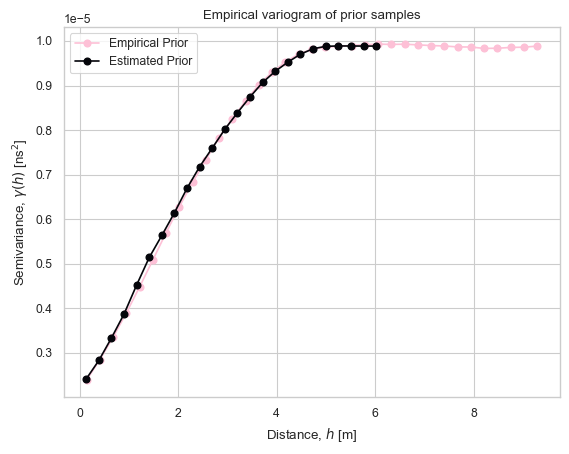

In [23]:
# Estimate variogram - Cache to disk since it takes a few minutes to run
bin_centers_est_sanity, gamma_est_sanity = mem.cache(gs.vario_estimate)(
    (model_grid_x, model_grid_y),
    prior_sanity_samples,
    mesh_type="structured",
)

plt.plot(bin_centers_est, gamma_est, "o-", color=colors(1), label="Empirical Prior")
plt.plot(bin_centers_est_sanity, gamma_est_sanity, "o-", color=colors(0), label="Estimated Prior")
plt.xlabel("Distance, $h$ [m]")
plt.ylabel("Semivariance, $γ(h)$ [ns$^2$]")
plt.title("Empirical variogram of prior samples")
plt.legend()

# Forward Model

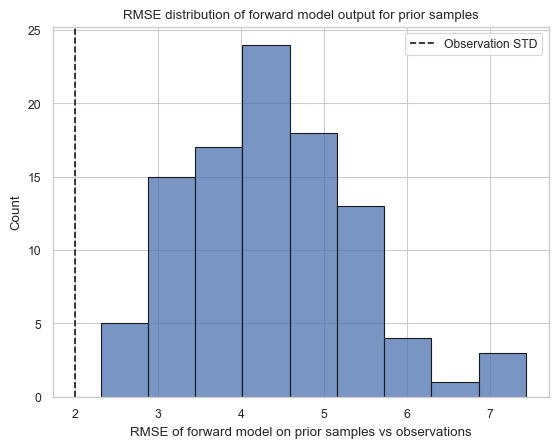

In [24]:
# forward_model_solver = "skfmm:fmm"
# forward_model_solver_kwargs = {
#     # These arguments are tuned to work well for my system, depends on GPU, CPU, and memory bandwidth.
#     "chunk_size": 16,  # Trade-off between memory use and parallelization overhead
#     "parallel_args": {
#         "n_jobs": 4,
#     }
# }

forward_model_solver = "nanopinv:fsm"
forward_model_solver_kwargs = {
    "max_iter": 10_000,
    "tolerance": 1e-5,
}

forward_model = build_travel_time_points(
    sources, receivers, model_grid_x, model_grid_y, solver=forward_model_solver, solver_kwargs=forward_model_solver_kwargs,
)

def rmse(diff):
    return jnp.linalg.norm(diff, ord=2) / jnp.sqrt(diff.size)


# Check that forward model gives reasonable output for samples from the prior
@eqx.filter_jit()
@eqx.filter_vmap(in_axes=0)
def test_forward_model(key):
    prior_sample = prior_dist(key)
    reconstruction = forward_model(prior_sample)
    diff = reconstruction - obs.data_obs
    rmse_value = rmse(diff)
    return rmse_value


keys = skey(n=100)
rmse_values = test_forward_model(keys)

sns.histplot(rmse_values, edgecolor="k")

# Compare against STD
plt.axvline(obs.data_std, color="k", linestyle="--", label="Observation STD")
plt.xlabel("RMSE of forward model on prior samples vs observations")
plt.title("RMSE distribution of forward model output for prior samples")
plt.legend()


# Likelihood


In [25]:
# Normally we would allow data_std to be an array as well, but here we know we have fixed STD for all observations,
# so we can make this constant and gain a bit of efficiency
@jax.jit(static_argnames=("data_std",))
def log_likelihood_gaussian(data, data_obs, data_std: float) -> Float[Array, ""]:
    """
    Compute the log-likelihood of observed data under a Gaussian noise model.
    """
    normalised_residual = (data_obs - data) / data_std
    log_likelihood = -0.5 * jnp.sum(normalised_residual**2)
    return jnp.sum(log_likelihood)


# Sampler

In [26]:
# Configuration
N_chains = 10
keep_interval = 10

init_step_size = 0.085

N_steps_pre_burn_in = 500

N_steps_tune_step_size_1 = 10_000
tune_interval_tune_step_size_1 = 1_000

target_chain_acceptance_rate = 0.25

learning_rate_step_size = 1.0
learning_rate_step_size_decay = 0.5

In [27]:
proposal_dist = ProposalDistribution(dist=prior_dist, step_size=init_step_size)
chain_template = ExtendedMetropolisChain(
    beta=1.0,
    proposal_dist=proposal_dist,
    log_likelihood_fn=log_likelihood_gaussian,
    forward_model=forward_model,
)

chain = ExtendedMetropolisChain(
    beta=1.0,
    proposal_dist=ProposalDistribution(dist=prior_dist, step_size=init_step_size),
    log_likelihood_fn=log_likelihood_gaussian,
    forward_model=forward_model,
)

chain_spec = make_pytree_spec(
    chain_template,
    {
        "*": None,  # Don't vectorize other fields
    },
)

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(None, None, 0, 0, None, None))
def emc_step_n(chain, N_steps, key, iter_state, observations, keep_interval):
    return chain.step_n(
        N_steps,
        key=key,
        iter_state=iter_state,
        observations=observations,
        keep_interval=keep_interval,
        progress=True,
    )



@eqx.filter_jit
@eqx.filter_vmap(in_axes=(0, None, None))
def init_states(k, c, obs_):
    return c.get_iteration_state(prior_dist(k), obs_)

In [28]:
# Pre burn-in

iter_state0 = chain.get_iteration_state(prior_dist(skey()), obs)

# Pre-burn-in
iter_state_burnt_in, pre_burn_in_history = chain.step_n(
    N_steps_pre_burn_in,
    key=skey(),
    iter_state=iter_state0,
    observations=obs,
    keep_interval=keep_interval,
    progress=True,
)

Sampling:   0%|          | 0/500 [00:00<?, ?it/s]

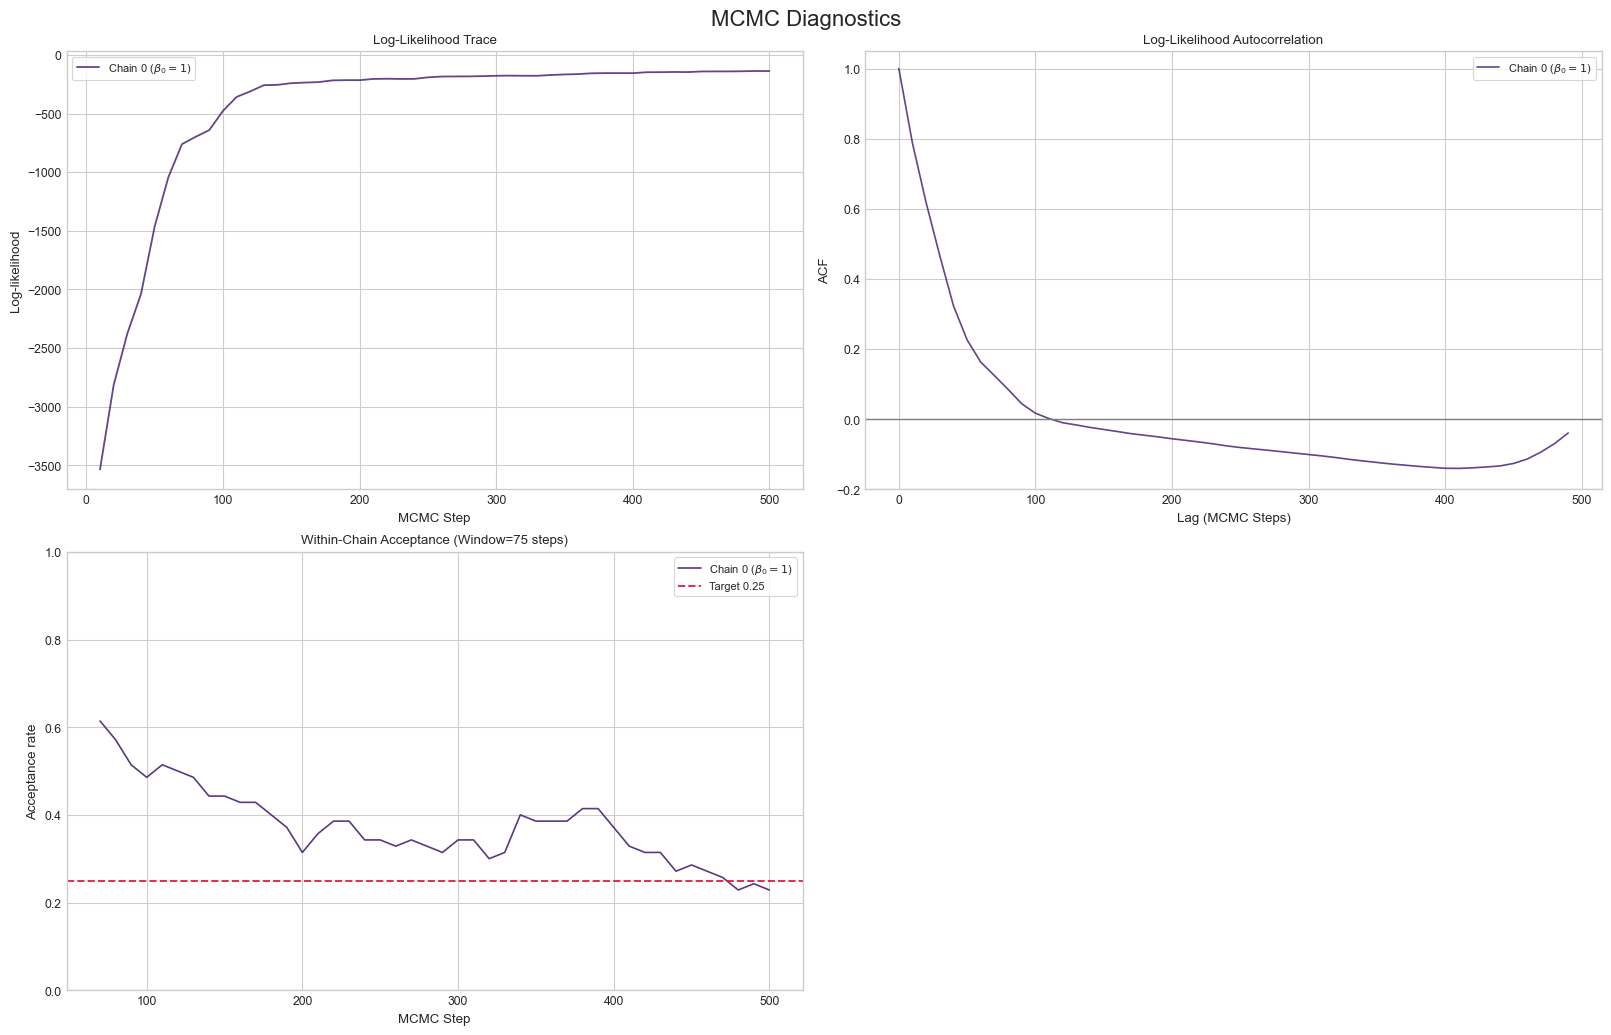

(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Log-Likelihood Trace'}, xlabel='MCMC Step', ylabel='Log-likelihood'>,
         <Axes: title={'center': 'Log-Likelihood Autocorrelation'}, xlabel='Lag (MCMC Steps)', ylabel='ACF'>],
        [<Axes: title={'center': 'Within-Chain Acceptance (Window=75 steps)'}, xlabel='MCMC Step', ylabel='Acceptance rate'>,
         <Axes: >]], dtype=object))

In [29]:
pre_burn_in_history.plot_diagnostics()

In [ ]:
# Tune step-sizes only
chain_tuned_1, iter_state_tuned_1, tune_history_1 = chain.tune(
    N_steps_tune_step_size_1,
    tune_interval_tune_step_size_1,
    key=skey(),
    iter_state=iter_state_burnt_in,
    observations=obs,
    keep_interval=keep_interval,
    target_acceptance_rate=target_chain_acceptance_rate,
    learning_rate=learning_rate_step_size,
    learning_rate_decay=learning_rate_step_size_decay,
    progress=True,
    inner_unroll=10,
)


Tuning:   0%|          | 0/10000 [00:00<?, ?it/s]

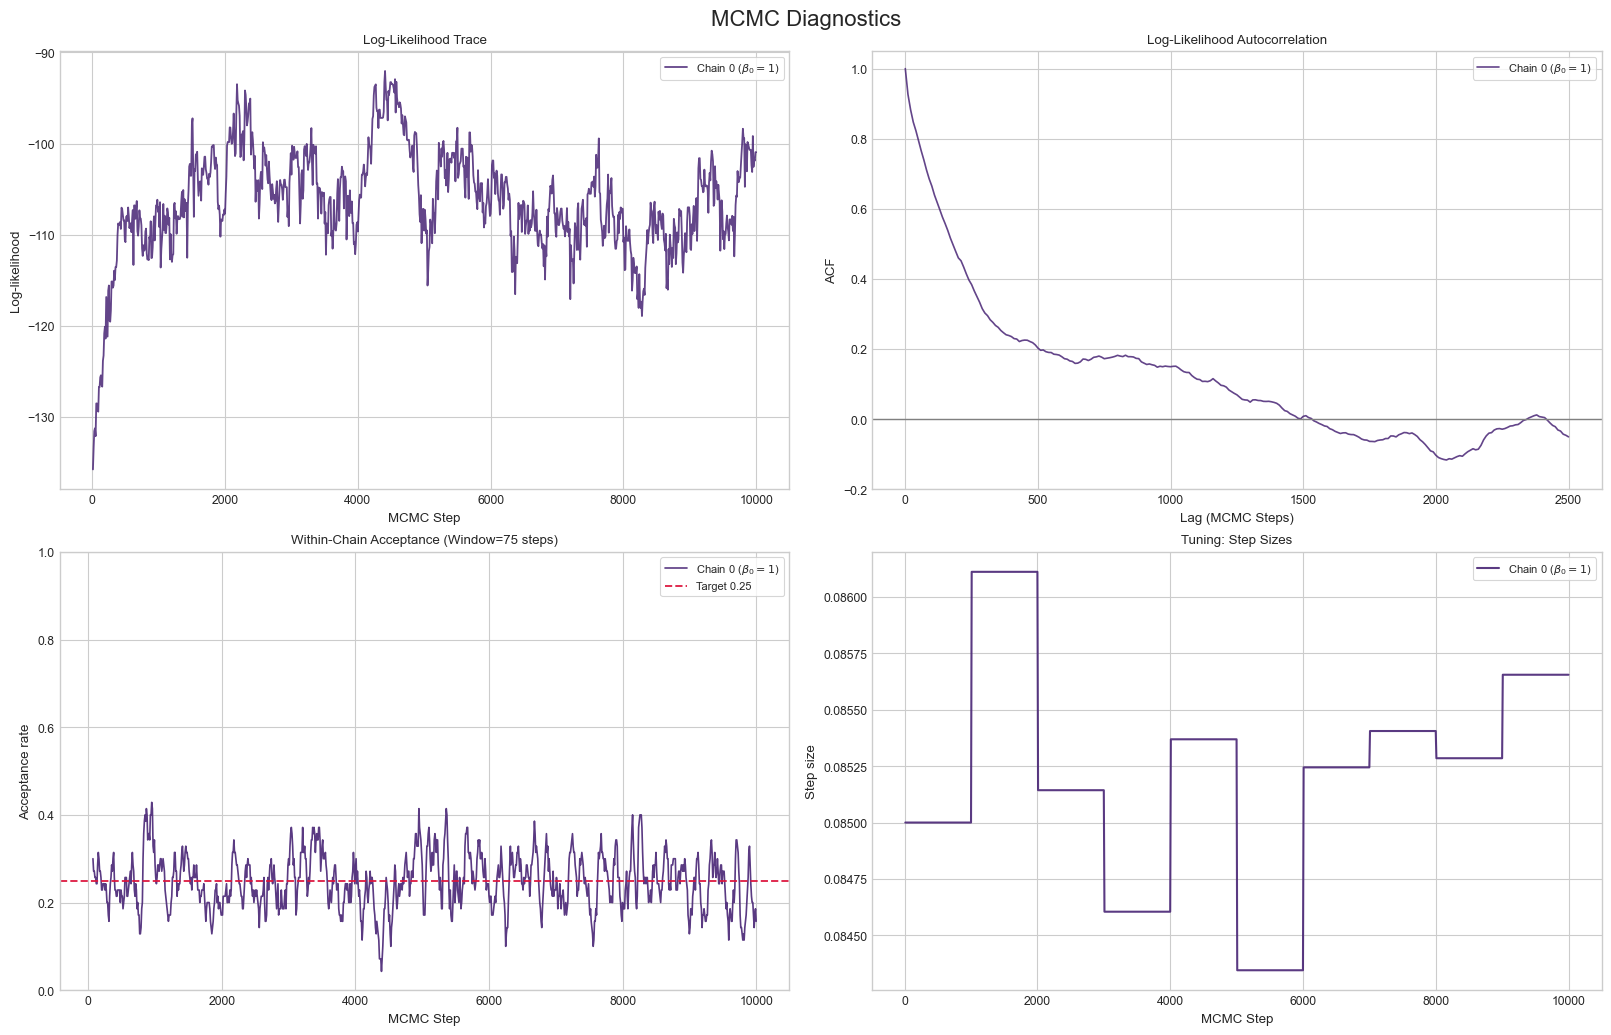

(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Log-Likelihood Trace'}, xlabel='MCMC Step', ylabel='Log-likelihood'>,
         <Axes: title={'center': 'Log-Likelihood Autocorrelation'}, xlabel='Lag (MCMC Steps)', ylabel='ACF'>],
        [<Axes: title={'center': 'Within-Chain Acceptance (Window=75 steps)'}, xlabel='MCMC Step', ylabel='Acceptance rate'>,
         <Axes: title={'center': 'Tuning: Step Sizes'}, xlabel='MCMC Step', ylabel='Step size'>]],
       dtype=object))

In [ ]:
tune_history_1.plot_diagnostics()

Sampling:   0%|          | 0/500 [00:00<?, ?it/s]

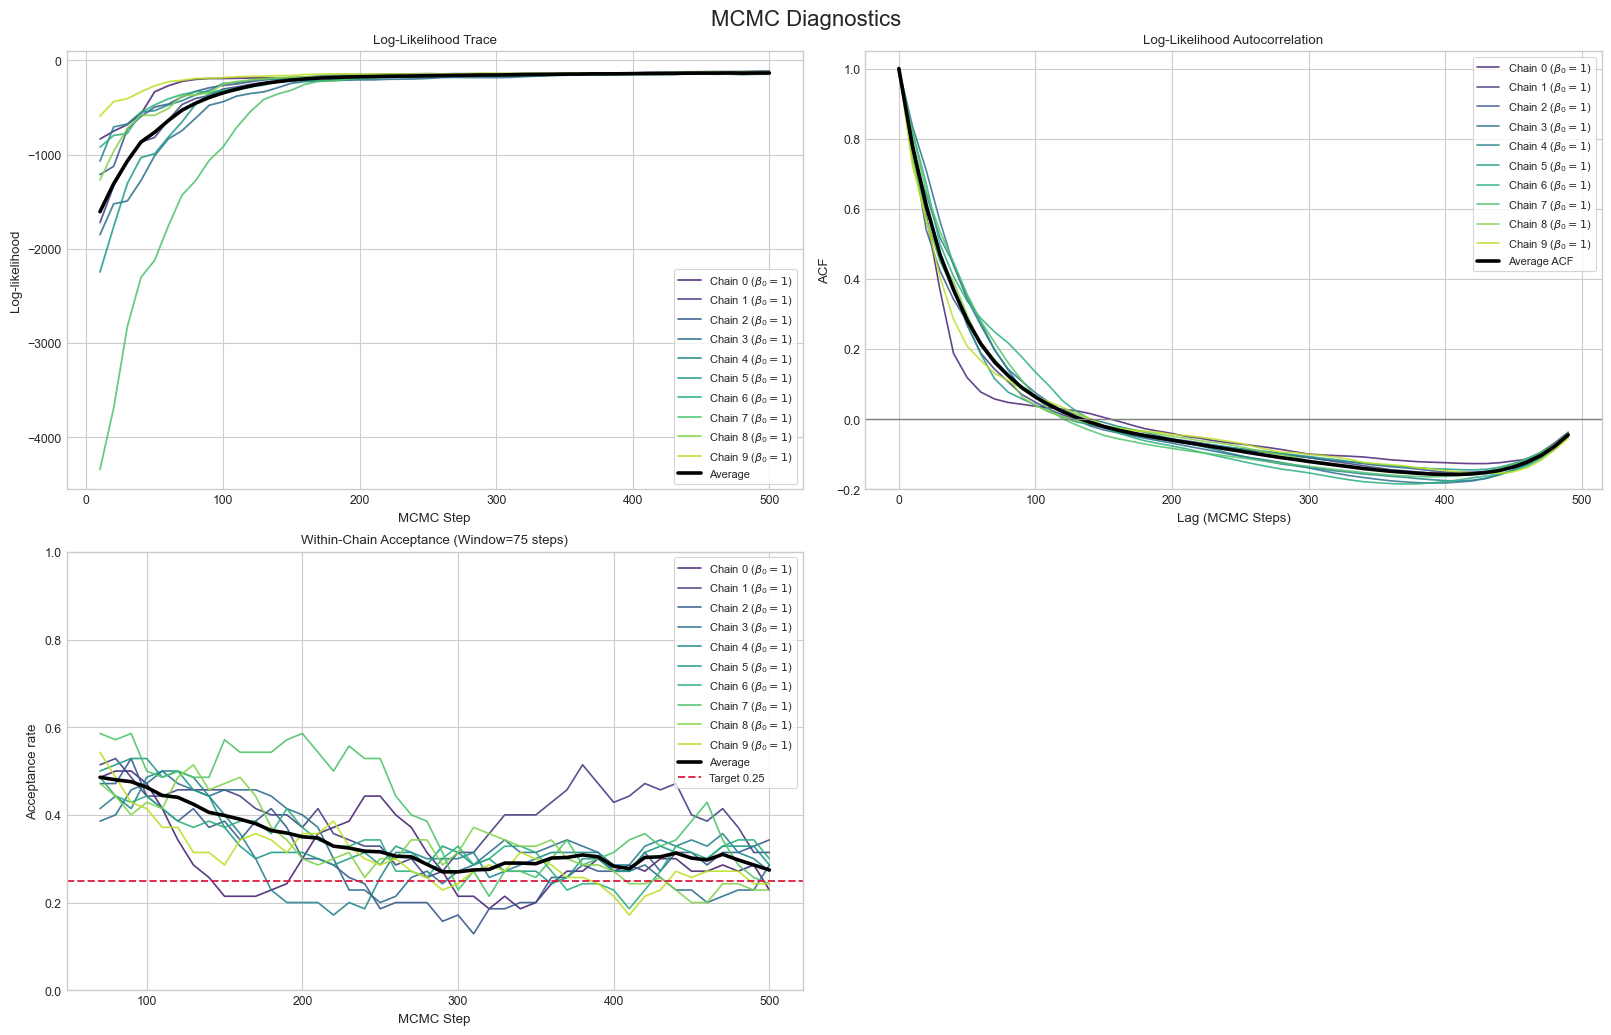

(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Log-Likelihood Trace'}, xlabel='MCMC Step', ylabel='Log-likelihood'>,
         <Axes: title={'center': 'Log-Likelihood Autocorrelation'}, xlabel='Lag (MCMC Steps)', ylabel='ACF'>],
        [<Axes: title={'center': 'Within-Chain Acceptance (Window=75 steps)'}, xlabel='MCMC Step', ylabel='Acceptance rate'>,
         <Axes: >]], dtype=object))

In [ ]:
# Vectorised for getting lots of samples
iter_states0 = init_states(skey(n=N_chains), chain_tuned_1, obs)
iter_states_burnt_in, burn_in_history = emc_step_n(
    chain_tuned_1,
    N_steps_pre_burn_in,
    key=skey(N_chains),
    iter_state=iter_states0,
    observations=obs,
    keep_interval=keep_interval,
)
burn_in_history.plot_diagnostics()


In [ ]:
# Small unperturbed sample to gauge correlation time
iter_states_unperturbed, unperturbed_history = emc_step_n(
    chain_tuned_1,
    3000,
    key=skey(N_chains),
    iter_state=iter_states_burnt_in,
    observations=obs,
    keep_interval=keep_interval,
)

Sampling:   0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
# Test flat states for EMC
unperturbed_history._get_states().shape

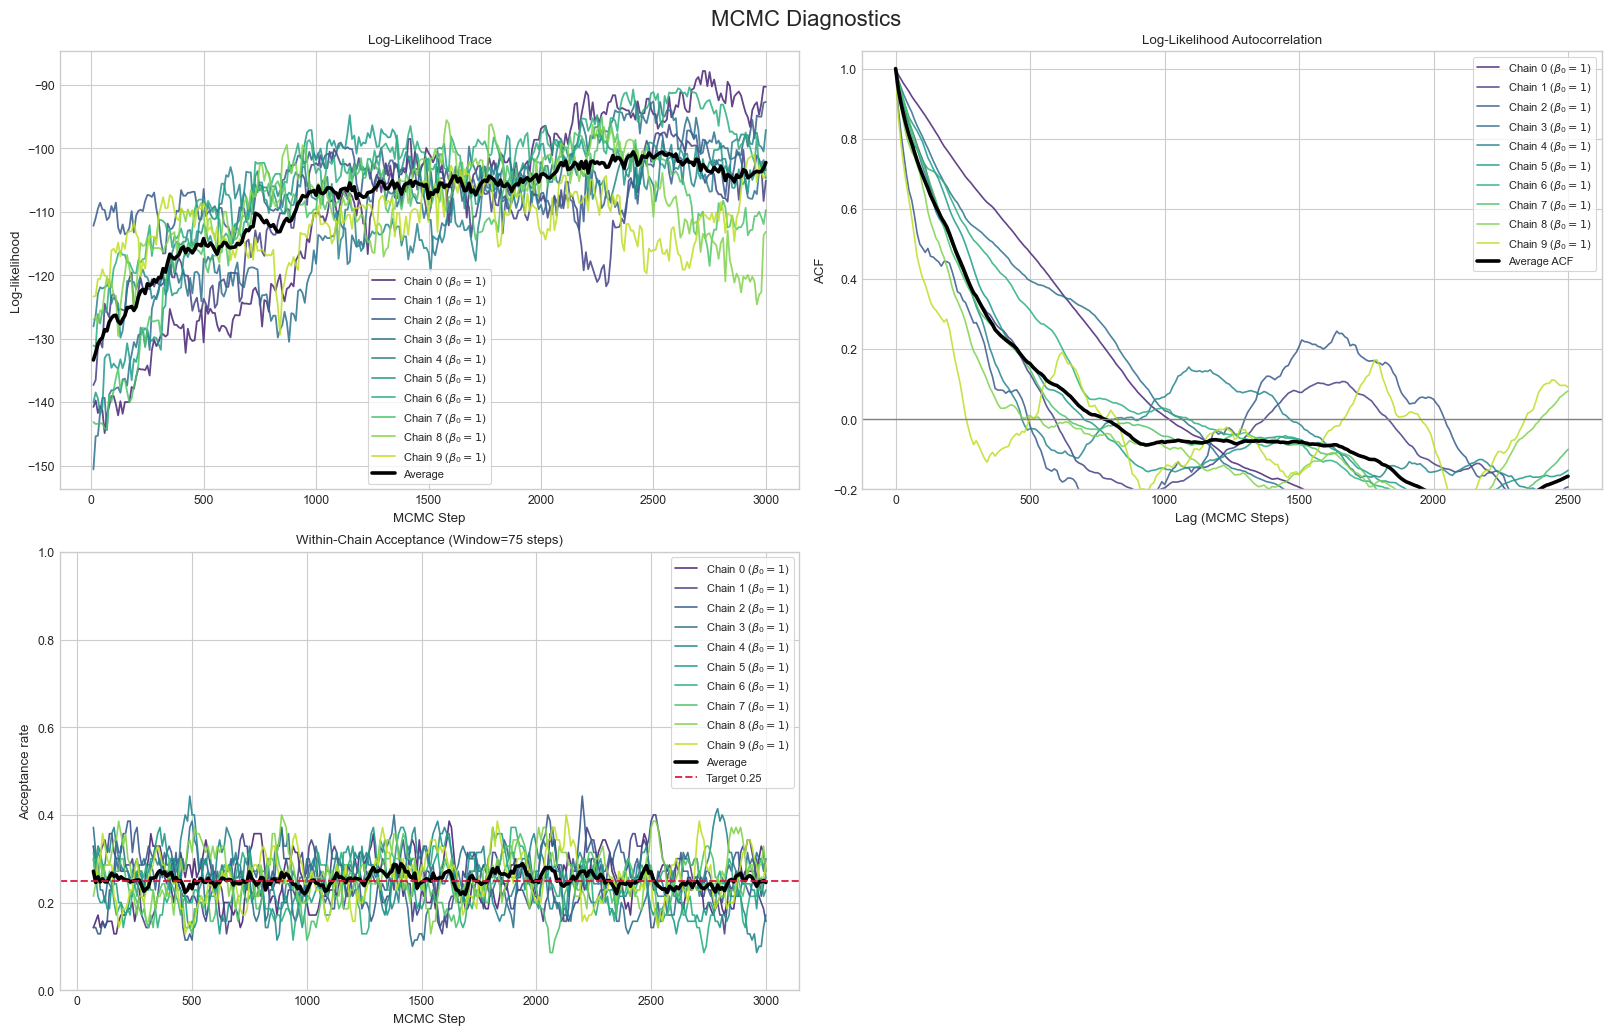

(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Log-Likelihood Trace'}, xlabel='MCMC Step', ylabel='Log-likelihood'>,
         <Axes: title={'center': 'Log-Likelihood Autocorrelation'}, xlabel='Lag (MCMC Steps)', ylabel='ACF'>],
        [<Axes: title={'center': 'Within-Chain Acceptance (Window=75 steps)'}, xlabel='MCMC Step', ylabel='Acceptance rate'>,
         <Axes: >]], dtype=object))

In [ ]:
unperturbed_history.plot_diagnostics()

In [ ]:
keep_interval_prod_2 = 1000
# Production run

iter_states_prod_1, prod_history_1 = emc_step_n(
    chain_tuned_1,
    10_000,
    key=skey(N_chains),
    iter_state=iter_states_unperturbed,
    observations=obs,
    keep_interval=keep_interval_prod_2,
)


Sampling:   0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
prod_history_1.plot_diagnostics(
    window_chain=tune_interval_tune_step_size_1,
)


Failed to reload module 'packaging.version' from file '/home/jkl/Code/DTU-30760-Inverse-Problems-and-Machine-Learning-in-Earth-and-Space-Physics/.pixi/envs/cuda/lib/python3.14/site-packages/packaging/version.py'
Traceback (most recent call last):
  File "/home/jkl/Code/DTU-30760-Inverse-Problems-and-Machine-Learning-in-Earth-and-Space-Physics/.pixi/envs/cuda/lib/python3.14/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jkl/Code/DTU-30760-Inverse-Problems-and-Machine-Learning-in-Earth-and-Space-Physics/.pixi/envs/cuda/lib/python3.14/site-packages/IPython/extensions/autoreload.py", line 625, in superreload
    update_generic(old_obj, new_obj)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "/home/jkl/Code/DTU-30760-Inverse-Problems-and-Machine-Learning-in-Earth-and-Space-Physics/.pixi/envs/cuda/lib/python3.14/site-packages/IPython/extensions/autoreload.py", line 451, i

# Posterior

(30, 41, 63)


<Axes: title={'center': 'Posterior Variance'}, xlabel='$x$ [m]', ylabel='$y$ [m]'>

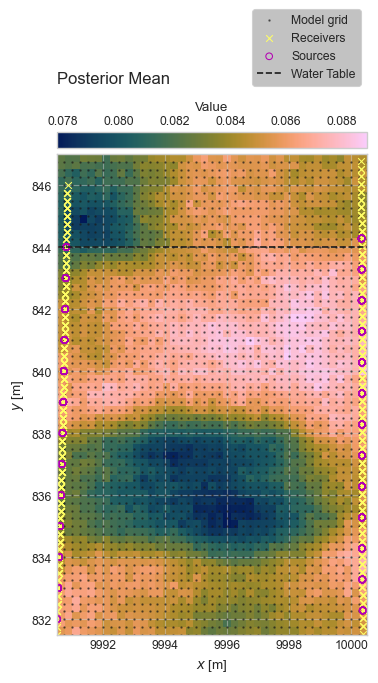

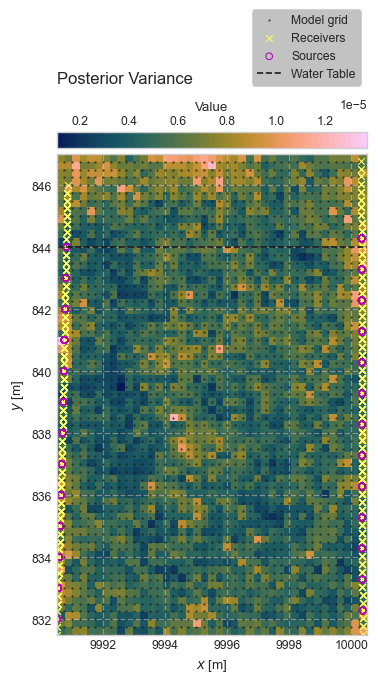

In [ ]:
# Get accepted states from cold chain (beta=1.0)
accepted_states = prod_history_1.get_flat_cold_accepted_states()
posterior_samples = accepted_states
print(posterior_samples.shape)

plot_field(posterior_samples.mean(axis=0), title="Posterior Mean")
plot_field(posterior_samples.var(axis=0), title="Posterior Variance")

In [ ]:
# Check that forward of posterior matches observations well
forward_posterior_samples = jax.vmap(forward_model)(posterior_samples)
forward_posterior_samples_mean = forward_posterior_samples.mean(axis=0)
forward_posterior_samples_p2_5 = jnp.percentile(forward_posterior_samples, 2.5, axis=0)
forward_posterior_samples_p97_5 = jnp.percentile(forward_posterior_samples, 97.5, axis=0)

# And get some prior samples too
prior_samples = prior_dist(skey(), num_samples=len(posterior_samples))
forward_prior_samples = jax.vmap(forward_model)(prior_samples)
forward_prior_samples_mean = forward_prior_samples.mean(axis=0)
forward_prior_samples_p2_5 = jnp.percentile(forward_prior_samples, 2.5, axis=0)
forward_prior_samples_p97_5 = jnp.percentile(forward_prior_samples, 95.5, axis=0)


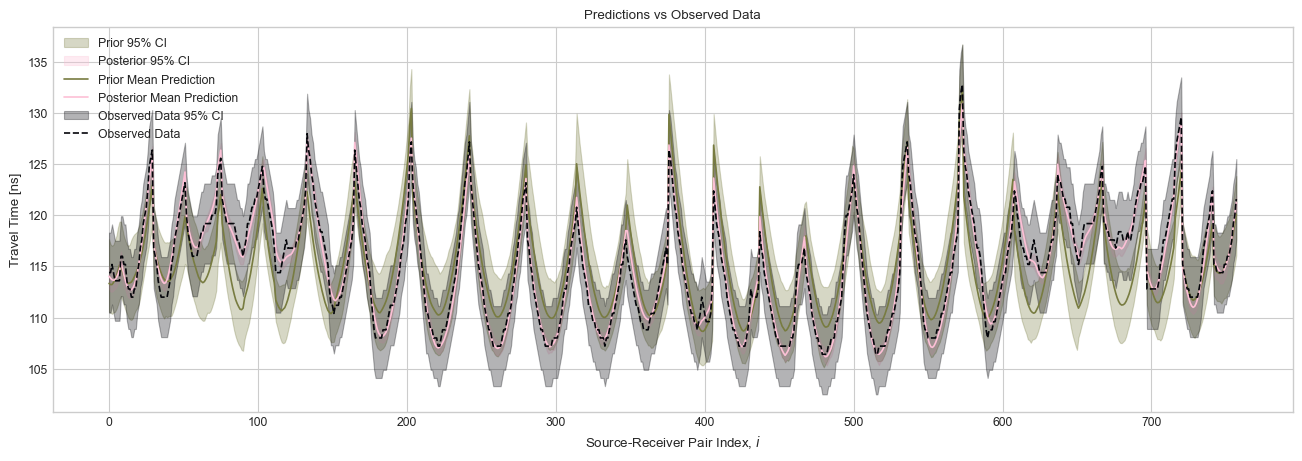

Ellipsis

In [ ]:
plt.figure(figsize=(16, 5))
i = jnp.arange(len(data_obs))

cm = cmc.batlowKS
alpha = 0.3

# Plot prior
plt.fill_between(
    i,
    forward_prior_samples_p2_5,
    forward_prior_samples_p97_5,
    color=cm(2),
    alpha=0.3,
    label="Prior 95% CI",
)

# Plot posterior
plt.fill_between(
    i,
    forward_posterior_samples_p2_5,
    forward_posterior_samples_p97_5,
    color=cm(1),
    alpha=0.3,
    label="Posterior 95% CI",
)

plt.plot(i, forward_prior_samples_mean, "-", label="Prior Mean Prediction", color=cm(2))
plt.plot(i, forward_posterior_samples_mean, "-", label="Posterior Mean Prediction", color=cm(1))

data_obs_p2_5 = data_obs - 1.96 * obs.data_std
data_obs_p97_5 = data_obs + 1.96 * obs.data_std
plt.fill_between(
    i,
    data_obs_p2_5,
    data_obs_p97_5,
    color=cm(0),
    alpha=0.3,
    label="Observed Data 95% CI",
)

plt.plot(i, data_obs, "--", label="Observed Data", color=cm(0))
plt.legend()
plt.xlabel("Source-Receiver Pair Index, $i$")
plt.ylabel("Travel Time [ns]")
plt.title("Predictions vs Observed Data")
plt.show()
...

Text(0.5, 1.0, 'Residuals of Prior and Posterior Predictions')

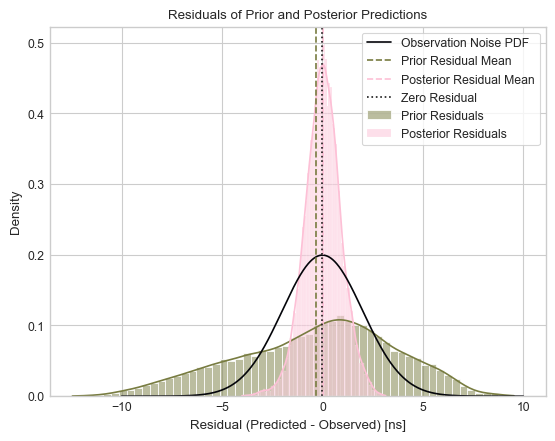

In [ ]:
# Residuals
residuals_prior = forward_prior_samples - data_obs
residuals_posterior = forward_posterior_samples - data_obs


sns.histplot(residuals_prior.flatten(), color=cm(2), label="Prior Residuals", kde=True, stat="density")
sns.histplot(residuals_posterior.flatten(), color=cm(1), label="Posterior Residuals", kde=True, stat="density")

# Plot observation noise distribution
x = np.linspace(-10, 10, 1000)
obs_noise_dist = (1 / (obs.data_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x / obs.data_std) ** 2)
plt.plot(x, obs_noise_dist, color=cm(0), label="Observation Noise PDF")

# Plot means
plt.axvline(residuals_prior.mean(), color=cm(2), linestyle="--", label="Prior Residual Mean")
plt.axvline(residuals_posterior.mean(), color=cm(1), linestyle="--", label="Posterior Residual Mean")
plt.axvline(0, color="k", linestyle=":", label="Zero Residual")

plt.legend(frameon=True)
plt.xlabel("Residual (Predicted - Observed) [ns]")
plt.title("Residuals of Prior and Posterior Predictions")

# Porosity and Total Water In Place

Total water in place: 29.02 m^3


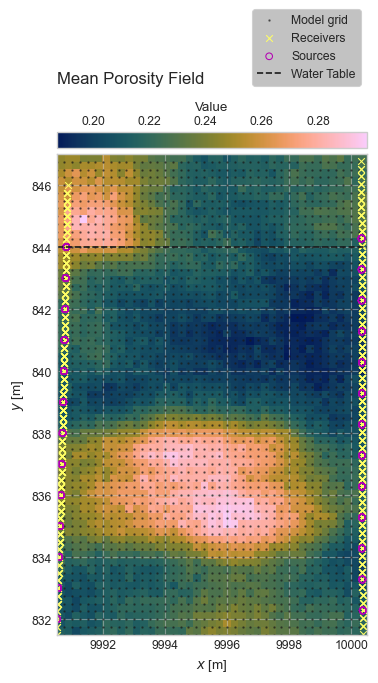

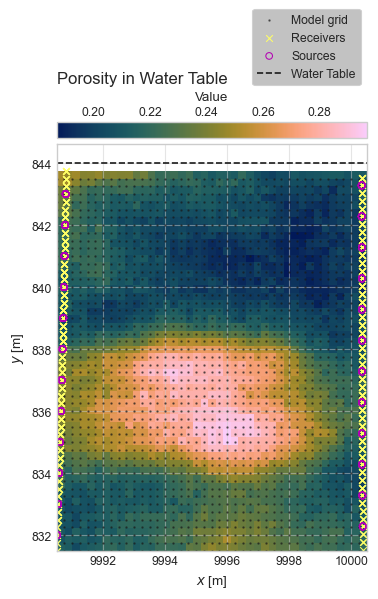

In [ ]:
# Water table definition
elevations = model_grid_y
water_table_elevation = 844.0
water_table_y = model_grid_y[model_grid_y < water_table_elevation]
extent_water_table = [
    np.min(model_grid_x),
    np.max(model_grid_x),
    np.min(water_table_y),
    np.max(water_table_y),
]


@eqx.filter_jit
def porosity(velocity):
    # Equation (1) from assignment
    return jnp.exp(-41.7 * velocity + 2.03)


def extract_water_table(field, elevations, cut_off_elevation: float):
    mask = elevations < cut_off_elevation
    water_table = field[:, mask]
    return water_table


mean_velocity_field = accepted_states.mean(axis=0)
mean_porosity_field = porosity(mean_velocity_field)

# Plot porosity
plot_field(mean_porosity_field, title="Mean Porosity Field")

# Plot porosity in water table
mean_porosity_water_table = extract_water_table(
    mean_porosity_field, elevations, water_table_elevation
)

plot_field(
    mean_porosity_water_table,
    title="Porosity in Water Table",
    extent=extent_water_table,
)


# Calculate TWIP
def total_water_in_place(porosity_field, model_grid_dx, model_grid_dy):
    total_porosity = jnp.sum(porosity_field)
    cell_area = model_grid_dx * model_grid_dy
    water_volume = total_porosity * cell_area
    return water_volume


total_water = total_water_in_place(
    mean_porosity_water_table, model_grid_dx, model_grid_dy
)
print(f"Total water in place: {total_water:.2f} m^3")

(30, 41, 50)


Array([29.24766206, 29.14677305, 29.14704097, 29.22380019, 29.12867745,
       29.14098335, 29.33797946, 29.07969231, 29.12629657, 29.12526072,
       29.14056949, 29.08130228, 29.27478987, 29.26504984, 29.25759851,
       29.01364603, 29.24168763, 29.10632566, 29.08714467, 29.17078117,
       29.08079414, 29.12232233, 29.06679064, 29.16992535, 29.01031811,
       29.02463711, 29.20821572, 29.11641354, 29.18934523, 29.14159122],      dtype=float64)

TWIP_posterior = 29.15 ± 0.08


Array([36.93949572, 36.71980341, 36.87597983, 37.07121323, 36.6548355 ,
       37.0961293 , 36.91063792, 37.04874314, 36.75095915, 36.68642426,
       37.12551856, 36.94028702, 37.02993473, 37.37617953, 37.06552759,
       36.6621271 , 36.73807931, 36.94359359, 37.23021387, 36.99432423,
       36.43654938, 36.70358537, 36.85396923, 36.91221758, 36.60695719,
       37.04844313, 36.82274357, 36.65619269, 37.07800991, 36.92779111],      dtype=float64)

<Axes: ylabel='Count'>

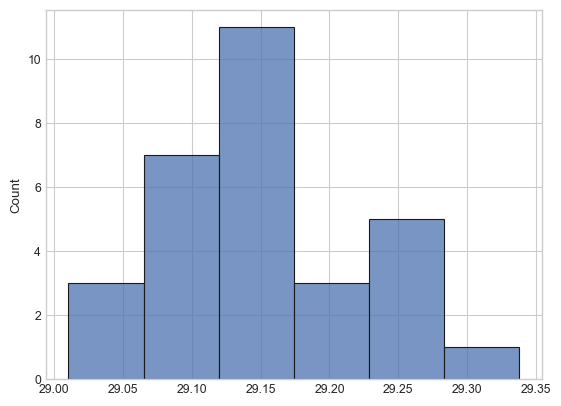

In [ ]:
# Calculate TWIP across all
water_table_mask = model_grid_y < water_table_elevation

accepted_velocity_fields_water_table = accepted_states[:, :, water_table_mask]
print(accepted_velocity_fields_water_table.shape)


@eqx.filter_vmap(in_axes=(0, None, None))
@jax.jit(
    static_argnames=(
        "model_grid_dx",
        "model_grid_dy",
    )
)
def total_water_in_place_from_velocity_field(
    velocity_field, model_grid_dx, model_grid_dy
) -> float:
    porosity_water_table = porosity(velocity_field)
    twip = total_water_in_place(porosity_water_table, model_grid_dx, model_grid_dy)

    return twip

twip_posterior = total_water_in_place_from_velocity_field(
    accepted_velocity_fields_water_table, model_grid_dx, model_grid_dy
)
display(twip_posterior)
twip_mean = twip_posterior.mean()
twip_sd = twip_posterior.std()
print(f"TWIP_posterior = {twip_mean:.2f} ± {twip_sd:.2f}")

display(
    total_water_in_place_from_velocity_field(
        accepted_states, model_grid_dx, model_grid_dy
    )
)

sns.histplot(twip_posterior, edgecolor="k")

In [ ]:
# Test the prior distribution
prior_velocity_fields = prior_dist(skey(), num_samples=100)
prior_velocity_fields_water_table = prior_velocity_fields[:, :, water_table_mask]
twip_prior = total_water_in_place_from_velocity_field(
    prior_velocity_fields_water_table, model_grid_dx, model_grid_dy
)

display(twip_prior)
twip_mean = twip_prior.mean()
twip_sd = twip_prior.std()

print(f"TWIP_prior = {twip_mean:.2f} ± {twip_sd:.2f}")
display(
    total_water_in_place_from_velocity_field(
        prior_velocity_fields, model_grid_dx, model_grid_dy
    )
)

Array([28.48256683, 28.67500741, 29.28367147, 28.69956337, 28.98314816,
       28.05377856, 29.61233032, 28.59482744, 28.06108074, 28.57376849,
       27.76581124, 28.91006327, 29.00472031, 29.53461481, 30.04330342,
       28.71942706, 27.83106574, 28.655091  , 28.24880609, 29.74797667,
       27.93429637, 28.88171836, 27.87033966, 27.1860596 , 28.85404996,
       28.51420523, 30.11881005, 28.78882656, 28.57570502, 28.61028145,
       26.85310686, 28.83475323, 28.12131557, 27.91319817, 27.31184182,
       29.02172339, 29.23259028, 28.76035945, 28.53973434, 28.1185652 ,
       26.84920656, 28.40820507, 27.82524902, 28.44758661, 27.03857716,
       28.47961009, 29.33160077, 27.96427076, 27.47024488, 28.43629302,
       28.22190824, 29.79769316, 30.35914392, 30.47743644, 27.13917128,
       29.29358666, 26.60877616, 28.74148182, 27.61474546, 28.94462791,
       28.1393868 , 27.53482235, 28.84458707, 27.13169597, 27.10978229,
       29.72523205, 27.15089446, 29.67730443, 28.85797855, 28.27

TWIP_prior = 28.48 ± 0.97


Array([35.98894566, 36.71743415, 37.30348206, 35.98370237, 36.29472958,
       35.1723443 , 37.99748207, 35.75664838, 35.54470234, 36.05993668,
       35.10340076, 36.47495426, 36.56505794, 37.34843176, 37.09629398,
       36.96814125, 35.87351361, 35.96028853, 35.55083873, 36.29995569,
       34.63719816, 35.84821107, 34.81086266, 34.76633608, 36.22838059,
       36.12220728, 38.63442461, 36.14758539, 36.08882368, 35.57478172,
       33.8570726 , 36.70107329, 35.96816092, 34.74546417, 35.13169892,
       36.76510809, 36.56233729, 36.38203158, 36.26031836, 35.76264989,
       34.35548155, 36.77491579, 34.88388641, 35.71237027, 34.74580395,
       35.13258081, 37.01710472, 34.8678595 , 35.4078865 , 36.06978866,
       35.74325235, 36.27123264, 37.4406865 , 37.73419632, 34.54722707,
       36.510337  , 33.32975862, 35.96054193, 35.27541103, 36.54906374,
       35.539572  , 34.39313233, 36.1771697 , 35.41227172, 33.75137571,
       37.11839395, 34.46906386, 36.75383425, 36.43423239, 36.18

<Axes: ylabel='Count'>

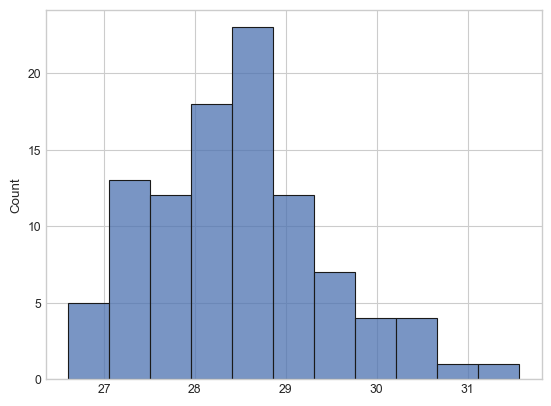

In [ ]:
sns.histplot(twip_prior, edgecolor="k", label="Prior")

In [ ]:
accepted_states.shape

(30, 41, 63)